In [2]:
import pandas as pd
import re
import json
import spacy
import medspacy
from medspacy.ner import TargetRule
from medspacy.context import ConTextRule
from medspacy.visualization import visualize_ent
import warnings
import seaborn as sns
import numpy as np
# from medspacy import 

warnings.filterwarnings("ignore")

/opt/anaconda3/envs/nlp-env/lib/python3.10/site-packages/requests/__init__.py:86: RequestsDependencyWarning: Unable to find acceptable character detection dependency (chardet or charset_normalizer).
  warnings.warn(


In [10]:
# df = pd.read_excel("./output/df_cleaned.xlsx")
df = pd.read_excel("./output/strat_sample_v1_cleaned_df.xlsx")
df = df[df["Annotation"].notna()].copy()

In [18]:
df.head()

,Unnamed: 0,YearConsult,Postcode,DatabaseName,ClinicCodeConsult,ConsultationNumber,PatientNumber,PatientTableID,VisitNumber,PatientBreed,PatientSex,PatientDateOfBirth,ExaminationText,Annotation,ID,AgeYears,BreedSize,AgeGroup,cleaned_examination_text
0,0,2019,40,RxQLD,24,21093402,8291436.0,399476,21084737,Mastiff,Female,2016-07-25,Reason: Check Everything. Vaccination History:...,No,RxQLD_24_399476_21084737,3,Large,Adult (3â€“7),reason check everything vaccination history no...
1,1,2019,42,RxQLD,65,21286453,8261942.0,325695,21277206,Golden Retriever,Female,2016-01-01,Appointment Notes:*********** Patient name: Sa...,No,RxQLD_65_325695_21277206,3,Large,Adult (3â€“7),appointment notes patient name salmon history ...
2,2,2019,45,RxQLD,91,21422451,8271339.0,237626,21412785,Irish Wolfhound,Female,2015-11-13,Appointment Notes:*********** Patient name: Pe...,No,RxQLD_91_237626_21412785,4,Large,Adult (3â€“7),appointment notes patient name pepper history ...
3,3,2019,25,RxNSW,231,25981180,7695019.0,250083,25957031,Maremma Sheepdog,Female,2010-10-01,Reason: Vaccination + Heartwrom (+worming?) Ap...,Yes,RxNSW_231_250083_25957031,9,Large,Mature (7â€“12),reason vaccination heartworm worming appointme...
4,4,2019,42,RxQLD,36,21106560,8293164.0,463736,21097850,American Staffordshire Terrier,Female,2009-09-19,Healthy Pets Wellness Testing: Done Yes / No V...,Yes,RxQLD_36_463736_21097850,10,Large,Mature (7â€“12),healthy pets wellness testing done yes no vacc...


In [12]:
nlp = medspacy.load()
target_matcher = nlp.get_pipe("medspacy_target_matcher")

### Target rules/patterns

In [13]:
eating_yes_patterns = [
    # Strong positive indicators
    TargetRule("eating and drinking normally", "EATING_YES", pattern=[{"LOWER": "eating"}, {"LOWER": "and"}, {"LOWER": "drinking"}, {"LOWER": "normally"}]),
    TargetRule("eating and drinking well", "EATING_YES", pattern=[{"LOWER": "eating"}, {"LOWER": "and"}, {"LOWER": "drinking"}, {"LOWER": "well"}]),
    TargetRule("eating well", "EATING_YES", pattern=[{"LOWER": "eating"}, {"LOWER": "well"}]),
    TargetRule("eating normally", "EATING_YES", pattern=[{"LOWER": "eating"}, {"LOWER": "normally"}]),
    TargetRule("eating fine", "EATING_YES", pattern=[{"LOWER": "eating"}, {"LOWER": "fine"}]),
    TargetRule("eating ok", "EATING_YES", pattern=[{"LOWER": "eating"}, {"LOWER": "ok"}]),
    
    # Appetite indicators
    TargetRule("good appetite", "EATING_YES", pattern=[{"LOWER": "good"}, {"LOWER": "appetite"}]),
    TargetRule("normal appetite", "EATING_YES", pattern=[{"LOWER": "normal"}, {"LOWER": "appetite"}]),
    TargetRule("appetite ok", "EATING_YES", pattern=[{"LOWER": "appetite"}, {"LOWER": "ok"}]),
    TargetRule("appetite remains", "EATING_YES", pattern=[{"LOWER": "appetite"}, {"LOWER": "remains"}]),
    TargetRule("appetite good", "EATING_YES", pattern=[{"LOWER": "appetite"}, {"LOWER": "good"}]),
    TargetRule("appetite is good", "EATING_YES", pattern=[{"LOWER": "appetite"}, {"LOWER": "is"}, {"LOWER": "good"}]),
    TargetRule("has appetite", "EATING_YES", pattern=[{"LOWER": "has"}, {"LOWER": {"IN": ["appetite", "his", "her"]}}, {"LOWER": "appetite"}]),
    
    # Owner reports
    TargetRule("owner reports eating well", "EATING_YES", pattern=[{"LOWER": "owner"}, {"LOWER": "reports"}, {"LOWER": "eating"}, {"LOWER": "well"}]),
    
    # Feeding/fed indicators
    TargetRule("feeding well", "EATING_YES", pattern=[{"LOWER": "feeding"}, {"LOWER": "well"}]),
    TargetRule("fed well", "EATING_YES", pattern=[{"LOWER": "fed"}, {"LOWER": "well"}]),
    
    # Food motivation
    TargetRule("food motivated", "EATING_YES", pattern=[{"LOWER": "food"}, {"LOWER": "motivated"}]),
    TargetRule("loves food", "EATING_YES", pattern=[{"LOWER": "loves"}, {"LOWER": "food"}]),
    TargetRule("keen on food", "EATING_YES", pattern=[{"LOWER": "keen"}, {"LOWER": "on"}, {"LOWER": "food"}]),
    
    # Happy eating
    TargetRule("happily eating", "EATING_YES", pattern=[{"LOWER": "happily"}, {"LOWER": "eating"}]),
    TargetRule("happy eating", "EATING_YES", pattern=[{"LOWER": "happy"}, {"LOWER": "eating"}]),
]

eating_no_patterns = [
    # Strong negative indicators
    TargetRule("not eating", "EATING_NO", pattern=[{"LOWER": "not"}, {"LOWER": "eating"}]),
    TargetRule("not really eating", "EATING_NO", pattern=[{"LOWER": "not"}, {"LOWER": "really"}, {"LOWER": "eating"}]),
    TargetRule("not eating well", "EATING_NO", pattern=[{"LOWER": "not"}, {"LOWER": "eating"}, {"LOWER": "well"}]),
    TargetRule("not eating anything", "EATING_NO", pattern=[{"LOWER": "not"}, {"LOWER": "eating"}, {"LOWER": "anything"}]),
    TargetRule("stopped eating", "EATING_NO", pattern=[{"LOWER": "stopped"}, {"LOWER": "eating"}]),
    
    # Appetite loss
    TargetRule("loss of appetite", "EATING_NO", pattern=[{"LOWER": "loss"}, {"LOWER": "of"}, {"LOWER": "appetite"}]),
    TargetRule("lost appetite", "EATING_NO", pattern=[{"LOWER": "lost"}, {"LOWER": {"IN": ["her", "his", "their", "appetite"]}}, {"LOWER": {"IN": ["appetite", "a"]}}]),
    TargetRule("reduced appetite", "EATING_NO", pattern=[{"LOWER": "reduced"}, {"LOWER": "appetite"}]),
    TargetRule("decreased appetite", "EATING_NO", pattern=[{"LOWER": "decreased"}, {"LOWER": "appetite"}]),
    TargetRule("poor appetite", "EATING_NO", pattern=[{"LOWER": "poor"}, {"LOWER": "appetite"}]),
    TargetRule("no appetite", "EATING_NO", pattern=[{"LOWER": "no"}, {"LOWER": "appetite"}]),
    TargetRule("losing appetite", "EATING_NO", pattern=[{"LOWER": "losing"}, {"LOWER": "appetite"}]),
    TargetRule("appetite is less", "EATING_NO", pattern=[{"LOWER": "appetite"}, {"LOWER": "is"}, {"LOWER": "less"}]),
    TargetRule("appetite slightly reduced", "EATING_NO", pattern=[{"LOWER": "appetite"}, {"LOWER": "slightly"}, {"LOWER": "reduced"}]),
    TargetRule("appetite has been on and off", "EATING_NO", pattern=[{"LOWER": "appetite"}, {"LOWER": "has"}, {"LOWER": "been"}, {"LOWER": "on"}, {"LOWER": "and"}, {"LOWER": "off"}]),
    
    # Clinical terms
    TargetRule("inappetence", "EATING_NO"),
    TargetRule("anorexia", "EATING_NO"),
    TargetRule("anorexic", "EATING_NO"),
    
    # Fussy/picky eating
    TargetRule("fussy eater", "EATING_NO", pattern=[{"LOWER": "fussy"}, {"LOWER": "eater"}]),
    TargetRule("fussy with eating", "EATING_NO", pattern=[{"LOWER": "fussy"}, {"LOWER": "with"}, {"LOWER": "eating"}]),
    TargetRule("not too keen on", "EATING_NO", pattern=[{"LOWER": "not"}, {"LOWER": "too"}, {"LOWER": "keen"}, {"LOWER": "on"}]),
    TargetRule("not keen on", "EATING_NO", pattern=[{"LOWER": "not"}, {"LOWER": "keen"}, {"LOWER": "on"}]),
    TargetRule("not interested in eating", "EATING_NO", pattern=[{"LOWER": "not"}, {"LOWER": "interested"}, {"LOWER": "in"}, {"LOWER": "eating"}]),
    
    # Hand feeding (indicates reluctance)
    TargetRule("only eating if hand fed", "EATING_NO", pattern=[{"LOWER": "only"}, {"LOWER": "eating"}, {"LOWER": "if"}, {"LOWER": "hand"}, {"LOWER": "fed"}]),
    TargetRule("eating out of hands", "EATING_NO", pattern=[{"LOWER": "eating"}, {"LOWER": "out"}, {"LOWER": "of"}, {"LOWER": "hands"}]),
    TargetRule("hand fed", "EATING_NO", pattern=[{"LOWER": "hand"}, {"LOWER": "fed"}]),
    
    # Partial eating
    TargetRule("partially eating", "EATING_NO", pattern=[{"LOWER": "partially"}, {"LOWER": "eating"}]),
    TargetRule("eating small amounts", "EATING_NO", pattern=[{"LOWER": "eating"}, {"LOWER": "small"}, {"LOWER": "amounts"}]),
    TargetRule("not eating his usual", "EATING_NO", pattern=[{"LOWER": "not"}, {"LOWER": {"IN": ["eating", "his"]}}, {"LOWER": {"IN": ["his", "her", "usual"]}}]),
]

# 2. DIET BRANDS
brand_patterns = [
    TargetRule("lyka", "DIET_BRAND"),
    TargetRule("royal canin", "DIET_BRAND", pattern=[{"LOWER": "royal"}, {"LOWER": "canin"}]),
    TargetRule("hills", "DIET_BRAND"),
    TargetRule("science diet", "DIET_BRAND", pattern=[{"LOWER": "science"}, {"LOWER": "diet"}]),
    TargetRule("blackjack", "DIET_BRAND"),
    TargetRule("black hawk", "DIET_BRAND", pattern=[{"LOWER": "black"}, {"LOWER": "hawk"}]),
    TargetRule("blackhawke", "DIET_BRAND"),
    TargetRule("nosh", "DIET_BRAND"),
    TargetRule("ziwi", "DIET_BRAND"),
    TargetRule("advance", "DIET_BRAND"),
    TargetRule("supercoat", "DIET_BRAND"),
    TargetRule("purina", "DIET_BRAND"),
    TargetRule("pedigree", "DIET_BRAND"),
    TargetRule("eukanuba", "DIET_BRAND"),
    TargetRule("prime", "DIET_BRAND"),
    TargetRule("wild pacific", "DIET_BRAND", pattern=[{"LOWER": "wild"}, {"LOWER": "pacific"}]),
    TargetRule("optimum", "DIET_BRAND"),
    TargetRule("james wellbeloved", "DIET_BRAND", pattern=[{"LOWER": "james"}, {"LOWER": "wellbeloved"}]),
    TargetRule("iams", "DIET_BRAND"),
    TargetRule("harrington", "DIET_BRAND"),
    TargetRule("arden grange", "DIET_BRAND", pattern=[{"LOWER": "arden"}, {"LOWER": "grange"}]),
    TargetRule("canagan", "DIET_BRAND"),
    
    # # Medications (sometimes mistaken for food)
    # TargetRule("prokolin", "MEDICATION"),
    # TargetRule("nexgard", "MEDICATION"),
    # TargetRule("bravecto", "MEDICATION"),
    # TargetRule("drontal", "MEDICATION"),
    # TargetRule("gabapentin", "MEDICATION"),
    # TargetRule("surolan", "MEDICATION"),
]

# 3. DIET TYPES
diet_type_patterns = [
    # Food format/type
    TargetRule("wet food", "DIET_TYPE", pattern=[{"LOWER": "wet"}, {"LOWER": "food"}]),
    TargetRule("dry food", "DIET_TYPE", pattern=[{"LOWER": "dry"}, {"LOWER": "food"}]),
    TargetRule("kibble", "DIET_TYPE"),
    TargetRule("biscuits", "DIET_TYPE"),
    TargetRule("tinned", "DIET_TYPE"),
    TargetRule("tinned food", "DIET_TYPE", pattern=[{"LOWER": "tinned"}, {"LOWER": "food"}]),
    TargetRule("pouch", "DIET_TYPE"),
    TargetRule("sachet", "DIET_TYPE"),
    TargetRule("treats", "DIET_TYPE"),
    
    # Raw/cooked
    TargetRule("raw", "DIET_TYPE"),
    TargetRule("raw meat", "DIET_TYPE", pattern=[{"LOWER": "raw"}, {"LOWER": "meat"}]),
    TargetRule("raw food", "DIET_TYPE", pattern=[{"LOWER": "raw"}, {"LOWER": "food"}]),
    TargetRule("barf", "DIET_TYPE"),
    TargetRule("cooked", "DIET_TYPE"),
    TargetRule("boiled", "DIET_TYPE"),
    TargetRule("home cooked", "DIET_TYPE", pattern=[{"LOWER": "home"}, {"LOWER": "cooked"}]),
    TargetRule("cooked food", "DIET_TYPE", pattern=[{"LOWER": "cooked"}, {"LOWER": "food"}]),
    
    # Special diets
    TargetRule("bland diet", "DIET_TYPE", pattern=[{"LOWER": "bland"}, {"LOWER": "diet"}]),
    TargetRule("puppy food", "DIET_TYPE", pattern=[{"LOWER": "puppy"}, {"LOWER": "food"}]),
    TargetRule("puppy formula", "DIET_TYPE", pattern=[{"LOWER": "puppy"}, {"LOWER": "formula"}]),
    TargetRule("senior food", "DIET_TYPE", pattern=[{"LOWER": "senior"}, {"LOWER": "food"}]),
    TargetRule("adult food", "DIET_TYPE", pattern=[{"LOWER": "adult"}, {"LOWER": "food"}]),
    
    # Specific foods
    TargetRule("table scraps", "DIET_TYPE", pattern=[{"LOWER": "table"}, {"LOWER": "scraps"}]),
    TargetRule("scraps", "DIET_TYPE"),
    TargetRule("bones", "DIET_TYPE"),
    TargetRule("pig ears", "DIET_TYPE", pattern=[{"LOWER": "pig"}, {"LOWER": "ears"}]),
    
    # Protein sources 
    TargetRule("chicken", "DIET_ITEM"),
    TargetRule("boiled chicken", "DIET_ITEM", pattern=[{"LOWER": "boiled"}, {"LOWER": "chicken"}]),
    TargetRule("chicken breast", "DIET_ITEM", pattern=[{"LOWER": "chicken"}, {"LOWER": "breast"}]),
    TargetRule("cooked chicken", "DIET_ITEM", pattern=[{"LOWER": "cooked"}, {"LOWER": "chicken"}]),
    TargetRule("beef", "DIET_ITEM"),
    TargetRule("lamb", "DIET_ITEM"),
    TargetRule("turkey", "DIET_ITEM"),
    TargetRule("kangaroo", "DIET_ITEM"),
    TargetRule("fish", "DIET_ITEM"),
    TargetRule("salmon", "DIET_ITEM"),
    TargetRule("tuna", "DIET_ITEM"),
    TargetRule("sardines", "DIET_ITEM"),
    TargetRule("duck", "DIET_ITEM"),
    TargetRule("venison", "DIET_ITEM"),
    TargetRule("rabbit", "DIET_ITEM"),
    TargetRule("pork", "DIET_ITEM"),
    TargetRule("mince", "DIET_ITEM"),
    TargetRule("chicken mince", "DIET_ITEM", pattern=[{"LOWER": "chicken"}, {"LOWER": "mince"}]),
    
    # Carbs/vegetables
    TargetRule("rice", "DIET_ITEM"),
    TargetRule("white rice", "DIET_ITEM", pattern=[{"LOWER": "white"}, {"LOWER": "rice"}]),
    TargetRule("cooked rice", "DIET_ITEM", pattern=[{"LOWER": "cooked"}, {"LOWER": "rice"}]),
    TargetRule("pasta", "DIET_ITEM"),
    TargetRule("potato", "DIET_ITEM"),
    TargetRule("sweet potato", "DIET_ITEM", pattern=[{"LOWER": "sweet"}, {"LOWER": "potato"}]),
    TargetRule("pumpkin", "DIET_ITEM"),
    TargetRule("vegetables", "DIET_ITEM"),
    TargetRule("greens", "DIET_ITEM"),
    TargetRule("carrot", "DIET_ITEM"),
    TargetRule("blueberries", "DIET_ITEM"),
]

# 4. EATING BEHAVIORS
behavior_patterns = [
    # GI symptoms
    TargetRule("vomiting", "BEHAVIOR_GI"),
    TargetRule("vomits", "BEHAVIOR_GI"),
    TargetRule("vomit", "BEHAVIOR_GI"),
    TargetRule("diarrhoea", "BEHAVIOR_GI"),
    TargetRule("diarrhea", "BEHAVIOR_GI"),
    TargetRule("loose stool", "BEHAVIOR_GI", pattern=[{"LOWER": "loose"}, {"LOWER": {"IN": ["stool", "stools"]}}]),
    TargetRule("soft stool", "BEHAVIOR_GI", pattern=[{"LOWER": "soft"}, {"LOWER": {"IN": ["stool", "stools"]}}]),
    TargetRule("bloody diarrhoea", "BEHAVIOR_GI", pattern=[{"LOWER": "bloody"}, {"LOWER": {"IN": ["diarrhoea", "diarrhea", "faeces"]}}]),
    TargetRule("blood in faeces", "BEHAVIOR_GI", pattern=[{"LOWER": "blood"}, {"LOWER": "in"}, {"LOWER": {"IN": ["faeces", "feces", "stool", "stools"]}}]),
    TargetRule("bloody faeces", "BEHAVIOR_GI", pattern=[{"LOWER": "bloody"}, {"LOWER": {"IN": ["faeces", "feces"]}}]),
    TargetRule("blood", "BEHAVIOR_GI"),
    TargetRule("constipation", "BEHAVIOR_GI"),
    TargetRule("constipated", "BEHAVIOR_GI"),
    TargetRule("nausea", "BEHAVIOR_GI"),
    TargetRule("retching", "BEHAVIOR_GI"),
    TargetRule("flatulence", "BEHAVIOR_GI"),
    TargetRule("bloating", "BEHAVIOR_GI"),
    TargetRule("regurgitation", "BEHAVIOR_GI"),
    
    # Normal indicators (important!)
    TargetRule("no vomiting or diarrhoea", "BEHAVIOR_NORMAL", pattern=[{"LOWER": "no"}, {"LOWER": "vomiting"}, {"LOWER": "or"}, {"LOWER": "diarrhoea"}]),
    TargetRule("no vomiting diarrhoea", "BEHAVIOR_NORMAL", pattern=[{"LOWER": "no"}, {"LOWER": "vomiting"}, {"LOWER": "diarrhoea"}]),
    TargetRule("no diarrhoea", "BEHAVIOR_NORMAL", pattern=[{"LOWER": "no"}, {"LOWER": {"IN": ["diarrhoea", "diarrhea"]}}]),
    TargetRule("no vomiting", "BEHAVIOR_NORMAL", pattern=[{"LOWER": "no"}, {"LOWER": "vomiting"}]),
    
    # Behavioral
    TargetRule("lethargic", "BEHAVIOR_GENERAL"),
    TargetRule("lethargy", "BEHAVIOR_GENERAL"),
    TargetRule("weakness", "BEHAVIOR_GENERAL"),
    TargetRule("tired", "BEHAVIOR_GENERAL"),
    
    # Eating behaviors
    TargetRule("fussy", "BEHAVIOR_EATING"),
    TargetRule("fussy eater", "BEHAVIOR_EATING", pattern=[{"LOWER": "fussy"}, {"LOWER": "eater"}]),
    TargetRule("grazing", "BEHAVIOR_EATING"),
    TargetRule("refusing", "BEHAVIOR_EATING"),
    TargetRule("picky", "BEHAVIOR_EATING"),
    TargetRule("picky eater", "BEHAVIOR_EATING", pattern=[{"LOWER": "picky"}, {"LOWER": "eater"}]),
    TargetRule("coprophagia", "BEHAVIOR_EATING"),
    
    # Weight related
    TargetRule("weight loss", "BEHAVIOR_WEIGHT", pattern=[{"LOWER": "weight"}, {"LOWER": "loss"}]),
    TargetRule("losing weight", "BEHAVIOR_WEIGHT", pattern=[{"LOWER": "losing"}, {"LOWER": "weight"}]),
    TargetRule("lost weight", "BEHAVIOR_WEIGHT", pattern=[{"LOWER": "lost"}, {"LOWER": {"IN": ["weight", "some"]}}]),
    TargetRule("weight gain", "BEHAVIOR_WEIGHT", pattern=[{"LOWER": "weight"}, {"LOWER": "gain"}]),
    TargetRule("gaining weight", "BEHAVIOR_WEIGHT", pattern=[{"LOWER": "gaining"}, {"LOWER": "weight"}]),
    TargetRule("not gaining weight", "BEHAVIOR_WEIGHT", pattern=[{"LOWER": "not"}, {"LOWER": "gaining"}, {"LOWER": "weight"}]),
    
    # Other
    TargetRule("thirst", "BEHAVIOR_GENERAL"),
    TargetRule("increased thirst", "BEHAVIOR_GENERAL", pattern=[{"LOWER": "increased"}, {"LOWER": "thirst"}]),
    TargetRule("polydipsia", "BEHAVIOR_GENERAL"),
]

# 5. DIET CHANGES 
diet_change_patterns = [
    # Change indicators
    TargetRule("changed to", "DIET_CHANGE", pattern=[{"LOWER": "changed"}, {"LOWER": "to"}]),
    TargetRule("changing to", "DIET_CHANGE", pattern=[{"LOWER": "changing"}, {"LOWER": "to"}]),
    TargetRule("switched to", "DIET_CHANGE", pattern=[{"LOWER": "switched"}, {"LOWER": "to"}]),
    TargetRule("switching to", "DIET_CHANGE", pattern=[{"LOWER": "switching"}, {"LOWER": "to"}]),
    TargetRule("transition to", "DIET_CHANGE", pattern=[{"LOWER": {"IN": ["transition", "transitioning"]}}, {"LOWER": "to"}]),
    TargetRule("started on", "DIET_CHANGE", pattern=[{"LOWER": "started"}, {"LOWER": "on"}]),
    TargetRule("starting on", "DIET_CHANGE", pattern=[{"LOWER": "starting"}, {"LOWER": "on"}]),
    TargetRule("moved to", "DIET_CHANGE", pattern=[{"LOWER": "moved"}, {"LOWER": "to"}]),
    TargetRule("moving to", "DIET_CHANGE", pattern=[{"LOWER": "moving"}, {"LOWER": "to"}]),
    TargetRule("trialing", "DIET_CHANGE"),
    TargetRule("trial", "DIET_CHANGE"),
    TargetRule("trying", "DIET_CHANGE"),
    
    # Discussion indicators
    TargetRule("discussed diet", "DIET_DISCUSSED", pattern=[{"LOWER": "discussed"}, {"LOWER": {"IN": ["diet", "food", "nutrition"]}}]),
    TargetRule("discuss diet", "DIET_DISCUSSED", pattern=[{"LOWER": "discuss"}, {"LOWER": {"IN": ["diet", "food", "nutrition"]}}]),
    TargetRule("diet discussed", "DIET_DISCUSSED", pattern=[{"LOWER": "diet"}, {"LOWER": "discussed"}]),
    TargetRule("food discussed", "DIET_DISCUSSED", pattern=[{"LOWER": "food"}, {"LOWER": "discussed"}]),
    TargetRule("discussed food", "DIET_DISCUSSED", pattern=[{"LOWER": "discussed"}, {"LOWER": "food"}]),
    TargetRule("recommended", "DIET_DISCUSSED"),
    TargetRule("suggest", "DIET_DISCUSSED"),
    TargetRule("suggested", "DIET_DISCUSSED"),
    
    # Plan indicators
    TargetRule("plan to change", "DIET_PLANNED", pattern=[{"LOWER": "plan"}, {"LOWER": "to"}, {"LOWER": "change"}]),
    TargetRule("planning to change", "DIET_PLANNED", pattern=[{"LOWER": "planning"}, {"LOWER": "to"}, {"LOWER": "change"}]),
    TargetRule("will change", "DIET_PLANNED", pattern=[{"LOWER": "will"}, {"LOWER": "change"}]),
    TargetRule("going to change", "DIET_PLANNED", pattern=[{"LOWER": "going"}, {"LOWER": "to"}, {"LOWER": "change"}]),
    
    # No change indicators
    TargetRule("no change", "DIET_NO_CHANGE", pattern=[{"LOWER": "no"}, {"LOWER": "change"}]),
    TargetRule("continue", "DIET_NO_CHANGE"),
    TargetRule("continuing", "DIET_NO_CHANGE"),
    TargetRule("same diet", "DIET_NO_CHANGE", pattern=[{"LOWER": "same"}, {"LOWER": {"IN": ["diet", "food"]}}]),
    TargetRule("same food", "DIET_NO_CHANGE", pattern=[{"LOWER": "same"}, {"LOWER": "food"}]),
]


In [14]:
all_targets = (
    eating_yes_patterns + eating_no_patterns +
    brand_patterns + diet_type_patterns +
    behavior_patterns + diet_change_patterns
)
target_matcher.add(all_targets)

### Context rules/patterns

In [15]:
context = nlp.get_pipe("medspacy_context")

In [ ]:

# ============================================================================
# CONTEXT RULES - EXPANDED based on patterns in YOUR 500 records
# ============================================================================

negation_rules = [
    # Most common negations (2147 "no", 689 "not" in your data!)
    ConTextRule("no", "NEGATED_EXISTENCE", direction="forward", max_scope=3),
    ConTextRule("not", "NEGATED_EXISTENCE", direction="forward", max_scope=2),  # REDUCED from 3 to 2
    ConTextRule("never", "NEGATED_EXISTENCE", direction="forward", max_scope=3),
    ConTextRule("without", "NEGATED_EXISTENCE", direction="forward", max_scope=3),
    ConTextRule("none", "NEGATED_EXISTENCE", direction="forward", max_scope=2),
    
    # Clinical negations from your data
    ConTextRule("denies", "NEGATED_EXISTENCE", direction="forward", max_scope=3),
    ConTextRule("denied", "NEGATED_EXISTENCE", direction="forward", max_scope=3),
    ConTextRule("refuses", "NEGATED_EXISTENCE", direction="forward", max_scope=2),
    ConTextRule("refused", "NEGATED_EXISTENCE", direction="forward", max_scope=2),
    ConTextRule("absence of", "NEGATED_EXISTENCE", direction="forward", max_scope=3),
    ConTextRule("free of", "NEGATED_EXISTENCE", direction="forward", max_scope=3),
    ConTextRule("negative for", "NEGATED_EXISTENCE", direction="forward", max_scope=3),
    
    # Patient name context - negates diet items that are actually patient names
    ConTextRule("patient name", "NEGATED_EXISTENCE", direction="forward", max_scope=2,
                allowed_types={"DIET_ITEM", "DIET_BRAND"}),
    ConTextRule("name", "NEGATED_EXISTENCE", direction="forward", max_scope=1,
                allowed_types={"DIET_ITEM", "DIET_BRAND"}),
    ConTextRule("called", "NEGATED_EXISTENCE", direction="forward", max_scope=1,
                allowed_types={"DIET_ITEM", "DIET_BRAND"}),
    ConTextRule("named", "NEGATED_EXISTENCE", direction="forward", max_scope=1,
                allowed_types={"DIET_ITEM", "DIET_BRAND"}),
]

temporality_rules = [
    # Historical 
    ConTextRule("history of", "HISTORICAL", direction="forward", max_scope=4),
    ConTextRule("history", "HISTORICAL", direction="forward", max_scope=1),  
    ConTextRule("previous", "HISTORICAL", direction="forward", max_scope=2),
    ConTextRule("previously", "HISTORICAL", direction="forward", max_scope=3),
    ConTextRule("past", "HISTORICAL", direction="forward", max_scope=2),
    ConTextRule("chronic", "HISTORICAL", direction="forward", max_scope=2),
    
    # Time references 
    ConTextRule("since", "HISTORICAL", direction="backward", max_scope=3),
    ConTextRule("ongoing", "HISTORICAL", direction="forward", max_scope=2),
    ConTextRule("recent", "HISTORICAL", direction="forward", max_scope=2),
    
    # Specific time periods 
    ConTextRule("last week", "HISTORICAL", direction="bidirectional", max_scope=3),
    ConTextRule("last month", "HISTORICAL", direction="bidirectional", max_scope=3),
    ConTextRule("yesterday", "HISTORICAL", direction="bidirectional", max_scope=2),
    ConTextRule("days ago", "HISTORICAL", direction="backward", max_scope=3),
    ConTextRule("weeks ago", "HISTORICAL", direction="backward", max_scope=3),
    ConTextRule("months ago", "HISTORICAL", direction="backward", max_scope=3),
    ConTextRule("ago", "HISTORICAL", direction="backward", max_scope=3),
    
    # Past tense markers
    ConTextRule("was", "HISTORICAL", direction="forward", max_scope=1),
    ConTextRule("were", "HISTORICAL", direction="forward", max_scope=1),
    ConTextRule("had been", "HISTORICAL", direction="forward", max_scope=3),
    ConTextRule("had", "HISTORICAL", direction="forward", max_scope=2),
]

hypothetical_rules = [
    # Conditional 
    ConTextRule("if", "HYPOTHETICAL", direction="forward", max_scope=5),
    
    # Modal verbs
    ConTextRule("may", "HYPOTHETICAL", direction="forward", max_scope=2),
    ConTextRule("might", "HYPOTHETICAL", direction="forward", max_scope=2),
    ConTextRule("could", "HYPOTHETICAL", direction="forward", max_scope=2),
    ConTextRule("would", "HYPOTHETICAL", direction="forward", max_scope=2),
    ConTextRule("will", "HYPOTHETICAL", direction="forward", max_scope=3),
    
    # Clinical recommendations 
    ConTextRule("recommend", "HYPOTHETICAL", direction="forward", max_scope=2),  # REDUCED from 3 to 2
    ConTextRule("recommended", "HYPOTHETICAL", direction="forward", max_scope=2),  # REDUCED from 3 to 2
    ConTextRule("advise", "HYPOTHETICAL", direction="forward", max_scope=2),  # REDUCED from 3 to 2
    ConTextRule("advised", "HYPOTHETICAL", direction="forward", max_scope=2),  # REDUCED from 3 to 2
    ConTextRule("suggest", "HYPOTHETICAL", direction="forward", max_scope=2),  # REDUCED from 3 to 2
    ConTextRule("suggested", "HYPOTHETICAL", direction="forward", max_scope=2),  # REDUCED from 3 to 2
    ConTextRule("trial", "HYPOTHETICAL", direction="bidirectional", max_scope=2),
    ConTextRule("consider", "HYPOTHETICAL", direction="forward", max_scope=3),
    ConTextRule("considering", "HYPOTHETICAL", direction="forward", max_scope=3),
    
    # Planning/future 
    ConTextRule("plan to", "HYPOTHETICAL", direction="forward", max_scope=4),
    ConTextRule("planning", "HYPOTHETICAL", direction="forward", max_scope=3),
    ConTextRule("possible", "HYPOTHETICAL", direction="bidirectional", max_scope=2),
    ConTextRule("potential", "HYPOTHETICAL", direction="forward", max_scope=2),
]

In [17]:
all_context = negation_rules + temporality_rules + hypothetical_rules
context.add(all_context)

In [19]:
visualize_ent(nlp(df["cleaned_examination_text"][1]))

2025-12-15 15:37:55.134 | DEBUG    | PyRuSH.PyRuSHSentencizer:predict:100 - [cpredict_split_gaps|call_id=0] [doc 0] Token 0 'appointment' marked as sentence start (span begin)
2025-12-15 15:37:55.135 | DEBUG    | PyRuSH.PyRuSHSentencizer:predict:100 - [cpredict_split_gaps|call_id=0] Token/tag mapping: [(appointment, True), (notes, False), (patient, False), (name, False), (salmon, False), (history, False), (vaccination, False), (and, False), (preheat, False), (in, False), (worming, False), (as, False), (well, False), (no, False), (health, False), (concerns, False), (examination, False), (bcs, False), (4, False), (5, False), (9, False), (slightly, False), (underweight, False), (has, False), (gained, False), (2, False), (kg, False), (since, False), (6, False), (months, False), (ago, False), (temperature, False), (â, False), (38, False), (5c, False), (heart, False), (rate, False), (100, False), (â, False), (â, False), (â, False), (â, False), (â, False), (â, False), (â, False), (â, False), 

In [20]:
df["cleaned_examination_text"][1]

'appointment notes patient name salmon history vaccination and preheat in worming as well no health concerns examination bcs 4 5 9 slightly underweight has gained 2kg since 6 months ago temperature â 38 5c heart rate 100 â â â â â â â â respiration â 20 â â â â â â â mm â pink â â â â â â â â cut 2s â moist general appearance â demeanor gait â â bar cardiovascular no murmur or arrhythmia auscultated ssfp respiratory clear bronchovesicular lung sound normal respiratory effort oral examination â and â â â â â â â dental score mild tartar on upper canine and upper carnassial otherwise g0 eyes ears no discharge from bilateral pinna no odorous smell clear conjunctiva and cornea integument no ectoparasites fleas seen normal hair coat lymph nodes submandibular lymph node was other lens not palpated abdomen palpation â soft comfortable abdomen genitourinary and musculoskeletal all four limbs ambulatory full lameness examination not performed nervous system normal mentation intact menace respon

In [105]:
def extract_eating_status(text):
    """
    Extract eating status from clinical text.
    Returns: 'Yes', 'No', or 'Unknown'
    """
    # Handle empty/null text
    if pd.isna(text) or str(text).strip() == "":
        return "Unknown"
    
    # Process text through NLP pipeline
    doc = nlp(text)
    
    eating_yes_count = 0
    eating_no_count = 0
    
    # Count eating indicators
    for ent in doc.ents:
        is_negated = ent._.is_negated
        is_historical = ent._.is_historical
        is_hypothetical = ent._.is_hypothetical
        
        # Only count current, non-hypothetical mentions
        if not is_historical and not is_hypothetical:
            if ent.label_ == "EATING_YES" and not is_negated:
                eating_yes_count += 1
            elif ent.label_ == "EATING_NO" and not is_negated:
                eating_no_count += 1
            elif ent.label_ == "BEHAVIOR_NORMAL":
                # "no vomiting or diarrhoea" implies patient IS eating
                eating_yes_count += 1
            
            # Handle double negation (e.g., "no loss of appetite" = positive)
            if ent.label_ == "EATING_NO" and is_negated:
                eating_yes_count += 1
    
    # Determine eating status
    if eating_no_count > eating_yes_count:
        return "No"
    elif eating_yes_count > eating_no_count:
        return "Yes"
    else:
        return "Unknown"

In [ ]:
eating_status = []
for idx, row in df.iterrows():
    
    text = row['cleaned_examination_text']
    status = extract_eating_status(text)
    eating_status.append(status)

# Add new column to dataframe
df['patient_eating'] = eating_status

2025-10-26 22:28:31.697 | DEBUG    | PyRuSH.PyRuSHSentencizer:predict:100 - [cpredict_split_gaps|call_id=11204] [doc 0] Token 0 'reason' marked as sentence start (span begin)
2025-10-26 22:28:31.698 | DEBUG    | PyRuSH.PyRuSHSentencizer:predict:100 - [cpredict_split_gaps|call_id=11204] Token/tag mapping: [(reason, True), (client, False), (present, False), (nurse, False), (healthy, False), (pets, False), (wellness, False), (testing, False), (done, False), (yes, False), (no, False), (vaccination, False), (type, False), (not, False), (sure, False), (intestinal, False), (worming, False), (nexgard, False), (a, False), (month, False), (ago, False), (heartworm, False), (prevention, False), (flea, False), (prevention, False), (tick, False), (control, False), (microchip, False), (insurance, False), (and, False), (healthy, False), (pets, False), (plus, False), (behavior, False), (concerns, False), (current, False), (medications, False), (current, False), (diet, False), (type, False), (of, False)

In [ ]:
def check_nutrition_info_present(text):
    """
    Check if ANY nutritional/dietary information is mentioned in the text.
    
    Returns:
        "Yes" if any diet items (brands, types, proteins, carbs) are mentioned
        "No" if no diet information found
    """
    if pd.isna(text) or text.strip() == "":
        return "No"
    
    doc = nlp(text)
    
    # Check if ANY diet-related entities exist
    # Exclude entities that are negated (e.g., patient names) or hypothetical
    diet_entities = [
        ent for ent in doc.ents 
        if ent.label_ in ["DIET_BRAND", "DIET_ITEM"]
        and not ent._.is_hypothetical  # Exclude recommendations for future
        and not ent._.is_negated  # Exclude patient names (negated by "patient name" context)
    ]
    
    return "Yes" if len(diet_entities) > 0 else "No"


In [22]:
df['nutrition_info_present'] = df['cleaned_examination_text'].apply(check_nutrition_info_present)

2025-12-15 15:38:37.259 | DEBUG    | PyRuSH.PyRuSHSentencizer:predict:100 - [cpredict_split_gaps|call_id=1] [doc 0] Token 0 'reason' marked as sentence start (span begin)
2025-12-15 15:38:37.260 | DEBUG    | PyRuSH.PyRuSHSentencizer:predict:100 - [cpredict_split_gaps|call_id=1] Token/tag mapping: [(reason, True), (check, False), (everything, False), (vaccination, False), (history, False), (not, False), (been, False), (to, False), (the, False), (vets, False), (in, False), (some, False), (time, False), (though, False), (did, False), (get, False), (desexed, False), (and, False), (had, False), (all, False), (puppy, False), (vaccinations, False), (earlier, False), (in, False), (life, False), (at, False), (gx, False), (forest, False), (lake, False), (generally, False), (well, False), (though, False), (sometimes, False), (left, False), (front, False), (leg, False), (seems, False), (to, False), (shake, False), (at, False), (rest, False), (but, False), (not, False), (seemingly, False), (painful

In [ ]:
def check_nutrition_info_present_batch(texts):
    results = []
    nlp.disable_pipes("medspacy_context")
    for doc in nlp.pipe(texts, batch_size=50):
        found = False
        for ent in doc.ents:
            if (
                ent.label_ in {"DIET_BRAND", "DIET_ITEM"}
                and not ent._.is_hypothetical
            ):
                found = True
                break
        results.append("Yes" if found else "No")

    return results

df['nutrition_info_present'] = df['cleaned_examination_text'].apply(check_nutrition_info_present)

2025-12-23 15:53:03.319 | DEBUG    | PyRuSH.PyRuSHSentencizer:predict:100 - [cpredict_split_gaps|call_id=4010] [doc 0] Token 0 'reason' marked as sentence start (span begin)
2025-12-23 15:53:03.320 | DEBUG    | PyRuSH.PyRuSHSentencizer:predict:100 - [cpredict_split_gaps|call_id=4010] Token/tag mapping: [(reason, True), (check, False), (everything, False), (vaccination, False), (history, False), (not, False), (been, False), (to, False), (the, False), (vets, False), (in, False), (some, False), (time, False), (though, False), (did, False), (get, False), (desexed, False), (and, False), (had, False), (all, False), (puppy, False), (vaccinations, False), (earlier, False), (in, False), (life, False), (at, False), (gx, False), (forest, False), (lake, False), (generally, False), (well, False), (though, False), (sometimes, False), (left, False), (front, False), (leg, False), (seems, False), (to, False), (shake, False), (at, False), (rest, False), (but, False), (not, False), (seemingly, False), (p

In [13]:
df.to_csv("./output/df_rulesClassification.csv")
df.to_excel("./output/df_rulesClassification.xlsx")

### Checking the classificaiton against the annotated data

In [26]:
from sklearn.metrics import confusion_matrix, classification_report, precision_recall_fscore_support, accuracy_score

precision, recall, f1, support = precision_recall_fscore_support(
    df['Annotation'], 
    df['nutrition_info_present'],
    average='weighted'
)

tn, fp, fn, tp = confusion_matrix(df['Annotation'],  df['nutrition_info_present']).ravel()
sensitivity = tp / (tp + fn)      # Recall for positive class
specificity = tn / (tn + fp)      # Recall for negative class

accuracy = accuracy_score(
    df['Annotation'], 
    df['nutrition_info_present'],
)

print("\n" + "="*70)
print("DETAILED METRICS")
print("="*70)
print(f"Accuracy:  {accuracy:.4f} ({accuracy*100:.2f}%)")
print(f"Precision: {precision:.4f} ({precision*100:.2f}%)")
print(f"Recall:    {recall:.4f} ({recall*100:.2f}%)")
print(f"F1-Score:  {f1:.4f} ({f1*100:.2f}%)")
print("="*70)
print("CLINICALLY RELEVANT METRICS")
print("="*70)
print(f"Accuracy:     {accuracy:.4f} ({accuracy*100:.2f}%)")
print(f"Sensitivity:  {sensitivity:.4f} ({sensitivity*100:.2f}%)")
print(f"Specificity:  {specificity:.4f} ({specificity*100:.2f}%)")
print("="*70)


DETAILED METRICS
Accuracy:  0.8277 (82.77%)
Precision: 0.8316 (83.16%)
Recall:    0.8277 (82.77%)
F1-Score:  0.8251 (82.51%)
CLINICALLY RELEVANT METRICS
Accuracy:     0.8277 (82.77%)
Sensitivity:  0.7202 (72.02%)
Specificity:  0.9110 (91.10%)


### Checking the classificaiton against the annotated data initial

In [68]:
uk_df = pd.read_excel("../Data/validation/DatasetD_sample_2025-09-22_Validation_Uttara.xlsx")
comparison_df = df.merge(
    uk_df[['Id', 'UK- Annotation']],  # Adjust column names as needed
    left_on='Id',  # Adjust to match your ID column in df
    right_on='Id',  # Adjust to match your ID column in manual_df
    how='inner'
)

comparison_df['manual_annotation'] = comparison_df['UK- Annotation']
comparison_df['automated_extraction'] = comparison_df['nutrition_info_present']
comparison_df['manual_annotation'] = comparison_df['manual_annotation'].str.strip().str.capitalize()
comparison_df['automated_extraction'] = comparison_df['automated_extraction'].str.strip().str.capitalize()

In [69]:
print(comparison_df['manual_annotation'].value_counts())
print("\n")
print(comparison_df['automated_extraction'].value_counts())

manual_annotation
Yes    2689
No      109
Name: count, dtype: int64


automated_extraction
Yes    2458
No      340
Name: count, dtype: int64


In [70]:
from sklearn.metrics import confusion_matrix, classification_report, precision_recall_fscore_support, accuracy_score

precision, recall, f1, support = precision_recall_fscore_support(
    comparison_df['manual_annotation'], 
    comparison_df['automated_extraction'],
    average='weighted'
)

accuracy = accuracy_score(
    comparison_df['manual_annotation'], 
    comparison_df['automated_extraction']
)

print("\n" + "="*70)
print("DETAILED METRICS")
print("="*70)
print(f"Accuracy:  {accuracy:.4f} ({accuracy*100:.2f}%)")
print(f"Precision: {precision:.4f} ({precision*100:.2f}%)")
print(f"Recall:    {recall:.4f} ({recall*100:.2f}%)")
print(f"F1-Score:  {f1:.4f} ({f1*100:.2f}%)")
print("="*70)


DETAILED METRICS
Accuracy:  0.8781 (87.81%)
Precision: 0.9457 (94.57%)
Recall:    0.8781 (87.81%)
F1-Score:  0.9067 (90.67%)


<Axes: >

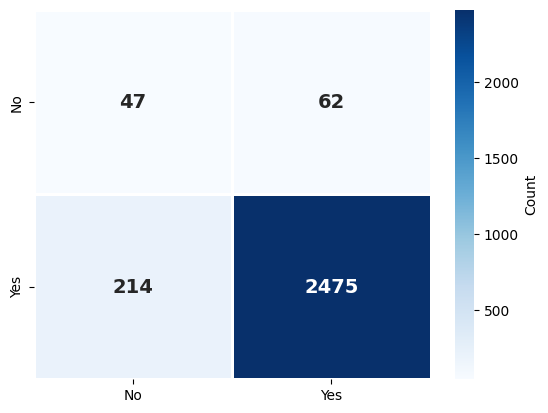

In [43]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(comparison_df['manual_annotation'], comparison_df['automated_extraction'])
annotations = []
for i in range(cm.shape[0]):
    row = []
    for j in range(cm.shape[1]):
        count = cm[i, j]
        row.append(count)
    annotations.append(row)

sns.heatmap(cm, annot=np.array(annotations), fmt='', cmap='Blues', 
            cbar_kws={'label': 'Count'},
            xticklabels=['No', 'Yes'],
            yticklabels=['No', 'Yes'],
            linewidths=2, linecolor='white',
            annot_kws={'size': 14, 'weight': 'bold'})


In [24]:
# Identify false positives and false negatives
false_positives = comparison_df[
    (comparison_df['manual_annotation'] == 'No') & 
    (comparison_df['automated_extraction'] == 'Yes')
].copy().reset_index()

false_negatives = comparison_df[
    (comparison_df['manual_annotation'] == 'Yes') & 
    (comparison_df['automated_extraction'] == 'No')
].copy().reset_index()

In [26]:
comparison_df.to_csv("./output/comparison_df.csv")
comparison_df.to_excel("./output/comparison_df.xlsx")

In [25]:
visualize_ent(nlp(false_positives["cleaned_examination_text"][0]))

2025-11-20 18:37:10.110 | DEBUG    | PyRuSH.PyRuSHSentencizer:predict:100 - [cpredict_split_gaps|call_id=5599] [doc 0] Token 0 'appointment' marked as sentence start (span begin)
2025-11-20 18:37:10.111 | DEBUG    | PyRuSH.PyRuSHSentencizer:predict:100 - [cpredict_split_gaps|call_id=5599] Token/tag mapping: [(appointment, True), (notes, False), (patient, False), (name, False), (lanka, False), (history, False), (2, False), (months, False), (ago, False), (couldn, False), (t, False), (hold, False), (her, False), (urine, False), (put, False), (onto, False), (poplin, False), (0, False), (3ml, False), (twice, False), (a, False), (day, False), (tried, False), (weaning, False), (her, False), (down, False), (but, False), (incontinence, False), (returned, False), (well, False), (controlled, False), (currently, False), (on, False), (0, False), (1ml, False), (twice, False), (daily, False), (eating, False), (and, False), (drinking, False), (normally, False), (was, False), (desexed, False), (early, 

In [52]:
check_nutrition_info_present(false_positives["cleaned_examination_text"][0])

2025-11-09 19:12:57.350 | DEBUG    | PyRuSH.PyRuSHSentencizer:predict:100 - [cpredict_split_gaps|call_id=5600] [doc 0] Token 0 'appointment' marked as sentence start (span begin)
2025-11-09 19:12:57.352 | DEBUG    | PyRuSH.PyRuSHSentencizer:predict:100 - [cpredict_split_gaps|call_id=5600] Token/tag mapping: [(appointment, True), (notes, False), (patient, False), (name, False), (lanka, False), (history, False), (2, False), (months, False), (ago, False), (couldn, False), (t, False), (hold, False), (her, False), (urine, False), (put, False), (onto, False), (poplin, False), (0, False), (3ml, False), (twice, False), (a, False), (day, False), (tried, False), (weaning, False), (her, False), (down, False), (but, False), (incontinence, False), (returned, False), (well, False), (controlled, False), (currently, False), (on, False), (0, False), (1ml, False), (twice, False), (daily, False), (eating, False), (and, False), (drinking, False), (normally, False), (was, False), (desexed, False), (early, 

'Yes'

In [72]:
false_positives["ExaminationText"][1]

'Reason: New Puppy History: New puppy adopted a few days ago EDUD well; had a little bit of diarrhoea initially but has settled with chicken and rice O would like to cook his meals - asked for advice. Recommended BalanceIt website . Also mentioned Lyka as an option. Emphasised that micronutirent balance is NNB Due for 2nd puppy vacc today Examination: Habitus BAR TPR WNL Lnn NAD Abd NAD Thoracic ausc clear Abd NAD Lnn NAD Eyes; ears; nose; mouth; skin; coat wnl No umbilical hernia No hindlimb dewclaws Both testes descended and located scrotally Laboratory: Assessment: Treatment: Consent has been given by the client to proceed with this treatment - Yes/No Plan: To give drontal in 2 weeks To give simparica/NS at next vac C3 booster in 4  weeks'

In [73]:
visualize_ent(nlp(false_positives["cleaned_examination_text"][1]))

2025-11-21 10:46:32.453 | DEBUG    | PyRuSH.PyRuSHSentencizer:predict:100 - [cpredict_split_gaps|call_id=11212] [doc 0] Token 0 'reason' marked as sentence start (span begin)
2025-11-21 10:46:32.455 | DEBUG    | PyRuSH.PyRuSHSentencizer:predict:100 - [cpredict_split_gaps|call_id=11212] Token/tag mapping: [(reason, True), (new, False), (puppy, False), (history, False), (new, False), (puppy, False), (adopted, False), (a, False), (few, False), (days, False), (ago, False), (dud, False), (well, False), (had, False), (a, False), (little, False), (bit, False), (of, False), (diarrhoea, False), (initially, False), (but, False), (has, False), (settled, False), (with, False), (chicken, False), (and, False), (rice, False), (owner, False), (would, False), (like, False), (to, False), (cook, False), (his, False), (meals, False), (asked, False), (for, False), (advice, False), (recommended, False), (balance, False), (website, False), (also, False), (mentioned, False), (lyka, False), (as, False), (an, F

In [62]:
false_positives["Id"][2]

6676791

In [61]:
# switch diet brand tags
# chicken and rice or any combinatgion with rice
# dog name is lyka
# stricting the diet brand tags

(62, 16)